In [3]:
import pandas as pd
import numpy as np
import os, sys, importlib, time
from tqdm import tqdm
tqdm.pandas()
sys.path.append(os.path.abspath(".."))
import matplotlib.pyplot as plt
%matplotlib inline

# models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

# myutils :
from utils import axe_classification
importlib.reload(axe_classification)
from utils.axe_classification import to_df_long, split_axe, emb_text
from utils.axe_classification import mlp_multilabels, predict_by_mlp, evaluate_model

# prepare data:

## import df_all:

In [ ]:
df_all=pd.read_csv("data/20251201-ProductionScientifiqueIRG-__-202512_2734art.csv")
print(len(df_all))
df_all['axe'].value_counts(dropna=False)

2734


axe
3          1107
1           684
NaN         617
2           252
4            46
1; 3         11
2; 3          8
1; 2          6
1; 2; 3       1
3; 1          1
3; 4          1
Name: count, dtype: int64

## split axe:

In [35]:
df_all=split_axe(df_all)
print(len(df_all))
display(df_all[['axe',"axe1","axe2","axe3","axe4",'axes_vec']].head())
df_all.head()

2734


,axe,axe1,axe2,axe3,axe4,axes_vec
0,NaN,0,0,0,0,"[0, 0, 0, 0]"
1,NaN,0,0,0,0,"[0, 0, 0, 0]"
2,NaN,0,0,0,0,"[0, 0, 0, 0]"
3,NaN,0,0,0,0,"[0, 0, 0, 0]"
4,NaN,0,0,0,0,"[0, 0, 0, 0]"


,halId_s,uri_s,docType_s,title_s,subTitle_s,authFullName_s,authIdHal_s,labStructName_s,author_primarystructure_s,collName_s,...,abstract_s,files_s,urlFulltextEsr_s,fnege_year,final_axe,axes_vec,axe1,axe2,axe3,axe4
0,hal-05388365,https://hal.science/hal-05388365v1,ART,Entrepreneuriat de nécessité (versus opportuni...,NaN,Nongainéba Benjamin Zoumba; Blaise Wendwaoga S...,NaN,Institut de Recherche en Gestion,57129_Institut de Recherche en Gestion;no prim...,Sciences de l'Homme et de la Société; Universi...,...,Cet article étudie les déterminants de l’entre...,NaN,NaN,2022,1; 3,"[0, 0, 0, 0]",0,0,0,0
1,hal-05388364,https://hal.science/hal-05388364v1,COMM,Responsible entrepreneurship: From motivations...,NaN,Nongainéba Benjamin Zoumba; Sandwidi Blaise We...,NaN,Institut de Recherche en Gestion,57129_Institut de Recherche en Gestion;57129_I...,NaN,...,Cet article étudie les déterminants des modèle...,https://hal.science/hal-05388364/file/aims2019...,NaN,2019,1; 3,"[0, 0, 0, 0]",0,0,0,0
2,hal-05385243,https://hal.science/hal-05385243v1,COMM,Agencer des safe spaces en marketing des servi...,NaN,Sacha Bensahel-Mercier; Amina Béji-Bécheur; So...,sacha-bensahel-mercier; amina-beji-becheur; so...,Institut de Recherche en Gestion; Institut de ...,1004418_Institut de Recherche en Gestion;57129...,Sciences de l'Homme et de la Société; Universi...,...,NaN,NaN,NaN,2022,2,"[0, 0, 0, 0]",0,0,0,0
3,hal-05384860,https://hal.science/hal-05384860v1,ART,The Financial Crisis of 1825: The Making of a ...,NaN,Nesrine Bentemessek Kahia,nesrine-bentemessek-kahia,Institut de Recherche en Gestion; Institut de ...,57129_Institut de Recherche en Gestion,Institut de Recherche en Gestion; Université P...,...,NaN,NaN,NaN,2022,4,"[0, 0, 0, 0]",0,0,0,0
4,hal-05383407,https://hal.science/hal-05383407v1,COMM,Repenser la responsabilité sociétale des marqu...,NaN,Philippe Jourdan; Jean-Claude Pacitto; Valérie...,philippe-jourdan,Institut de Recherche en Gestion; IUT Creteil-...,784_Centre d'études et de recherches appliquée...,Sciences de l'Homme et de la Société; Universi...,...,Cet article propose une grille intégrée d'anal...,https://hal.science/hal-05383407/file/20250627...,NaN,2022,1,"[0, 0, 0, 0]",0,0,0,0


## emb_text

In [ ]:
# load embeddings model:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer("BAAI/bge-m3")

# filtrage : no NaN in train data !
df_clean = df_all[(df_all["Axe"].notna())&(df_all['Axe']!='nan')].copy()#去掉nan
df=df_clean.copy()
print(f"[CHECK] all false :{df.Axe.isna().value_counts()}")

# embdder séparement les 3 cols:
for col_text in ['title_s','keyword_s','abstract_s']:
    df= emb_text(df=df, model=embedding_model, batch_size=32, col_text=col_text, col_emb=f"emb_{col_text}", 
                     pq_path=pq_path)

# save :
df.to_parquet(pq_path)
print(f"[SAVE] emb_all saved !")


In [2]:
# load emb:
pq_path="../external_data/df_clean_3emb.parquet"
df_all=pd.read_parquet(pq_path)
print(len(df_all))
display(df_all[["halId_s","axe",'title_s','keyword_s','abstract_s', 'emb_title_s','emb_keyword_s','emb_abstract_s']].head())

2117


,halId_s,axe,title_s,keyword_s,abstract_s,emb_title_s,emb_keyword_s,emb_abstract_s
14,hal-05354091,3,Les jeux vidéo FLOSS dans l’enseignement supér...,Ludopédagogie; EdUTeam,Dans le cadre du projet pédagogique et de rech...,"[-0.07416533, -0.02507004, -0.056212127, -0.00...","[-0.038245093, -0.003676773, -0.055256307, -0....","[-0.0627323, -0.012661392, -0.04260565, -0.003..."
20,hal-05321456,3,Unlocking Organizational Identity,,,"[-0.022757635, -0.0064444183, -0.042470817, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
33,hal-05302743,3,Les Remote Carriers dans le combat collaborati...,,Les Remote Carriers sont de systèmes complexes...,"[-0.03761582, -0.006678919, -0.009912152, 0.01...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.074023664, 0.021094285, -0.00791859, 0.025..."
40,hal-05295448,3,Frugalité technologique et ludopédagogie en ma...,EdUTeam; Jeux vidéo; Frugalité technologique; ...,Dans le cadre du projet pédagogique et de rech...,"[-0.081040576, 0.0018408684, -0.008541116, 0.0...","[-0.062362764, -0.028598065, -0.051758498, -0....","[-0.07686497, -0.0064801904, -0.03617584, -0.0..."
42,hal-05288245,3,Perspectives pédagogiques ! Frugalité technolo...,Jeux video; Frugalité technologique; Ludopédag...,Les travaux présentés dans ce chapitre font éc...,"[-0.09261081, -0.01070483, -0.017841782, 0.000...","[-0.054620333, -0.028326109, -0.0541471, 0.001...","[-0.07495657, 0.0016563429, -0.018859863, 0.01..."


<!-- ## to_df_long: -->

In [37]:
pq_long_path="../external_data/df_clean_3emb_long.parquet"
df_long=to_df_long(df_all, cols=['emb_title_s','emb_keyword_s','emb_abstract_s'], 
                pq_long_path=pq_long_path)
print(f"len df long (X): {len(df_long)}")
display(df_long.head())


[SAVE] df_long saved to ../external_data/df_clean_3emb_long.parquet!
len df long (X): 4767


,text_emb,halId_s,source,axe1,axe2,axe3,axe4,source_id,source_vec
0,"[-0.07416533, -0.02507004, -0.056212127, -0.00...",hal-05354091,title,0.0,0.0,1.0,0.0,0,"[1.0, 0.0, 0.0]"
1,"[-0.038245093, -0.003676773, -0.055256307, -0....",hal-05354091,keyword,0.0,0.0,1.0,0.0,1,"[0.0, 1.0, 0.0]"
2,"[-0.0627323, -0.012661392, -0.04260565, -0.003...",hal-05354091,abstract,0.0,0.0,1.0,0.0,2,"[0.0, 0.0, 1.0]"
3,"[-0.022757635, -0.0064444183, -0.042470817, 0....",hal-05321456,title,0.0,0.0,1.0,0.0,0,"[1.0, 0.0, 0.0]"
4,"[-0.03761582, -0.006678919, -0.009912152, 0.01...",hal-05302743,title,0.0,0.0,1.0,0.0,0,"[1.0, 0.0, 0.0]"


# train models:

## mlp：

In [11]:
import pandas as pd
import torch 
import numpy as np
from sklearn.model_selection import train_test_split

pq_long_path="../external_data/df_clean_3emb_long.parquet"

#-------------------------------- load data---------------------------------------
df=pd.read_parquet(pq_long_path)
X = np.concatenate([df["text_emb"].tolist(), df["source_vec"].tolist()], axis=1)
#text+source=1024+3=1027
y = df[['axe1','axe2','axe3','axe4']].values.astype(np.float32)
print(f"[INFO]input shape : {X.shape}, {y.shape}")

#-------------------------------- split data---------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

[INFO]input shape : (4767, 1027), (4767, 4)


In [12]:
importlib.reload(auto_completion)
from utils.auto_completion import mlp_multilabels

batch_size=32
dropout=0.5
n_epochs =40
patience=5
to_oversampling=True
mlp_model_path="sandbox_model/test_mlp_3emb_2.pt"
# mlp_model_path="../model/best_mlp_3emb_2.pt"

#-------------------------------- train mlp model---------------------------------------
mlp_model, best_t_overall=mlp_multilabels(X_train, X_val, y_train, y_val, 
                                      batch_size=batch_size,dropout=dropout, n_epochs =n_epochs, 
                                      patience=10,to_oversampling=to_oversampling, 
                                      model_path=mlp_model_path)
print(f"[INFO]le meilleure seuil pour chaque classe :\n{best_t_overall}\n")


[INFO] y_train before oversampling:[1257.  483. 2040.   90.]
After oversampling: [1281. 1449. 2086.  450.]
Dataset X shape: torch.Size([954, 1027]) y shape: torch.Size([954, 4])
Dataset X shape: torch.Size([5139, 1027]) y shape: torch.Size([5139, 4])
Epoch 1/40 | Train Loss: 0.0608 | Val Loss: 0.0469 | F1_macro: 0.6129

Epoch 2/40 | Train Loss: 0.0422 | Val Loss: 0.0454 | F1_macro: 0.6273

Epoch 3/40 | Train Loss: 0.0391 | Val Loss: 0.0479 | F1_macro: 0.6380

Epoch 4/40 | Train Loss: 0.0357 | Val Loss: 0.0442 | F1_macro: 0.6441

Epoch 5/40 | Train Loss: 0.0340 | Val Loss: 0.0426 | F1_macro: 0.6443

Epoch 6/40 | Train Loss: 0.0336 | Val Loss: 0.0449 | F1_macro: 0.6585

Epoch 7/40 | Train Loss: 0.0320 | Val Loss: 0.0437 | F1_macro: 0.6553

Epoch 8/40 | Train Loss: 0.0305 | Val Loss: 0.0395 | F1_macro: 0.6684

Epoch 9/40 | Train Loss: 0.0295 | Val Loss: 0.0437 | F1_macro: 0.6593

Epoch 10/40 | Train Loss: 0.0285 | Val Loss: 0.0427 | F1_macro: 0.6680

Epoch 11/40 | Train Loss: 0.0273 | Val

Micro  F1:  0.7793896948474237
Macro  F1:  0.6336343553851139
Micro Precision: 0.8030927835051547
Micro Recall: 0.7570456754130224
Hamming loss: 0.11556603773584906
Subset exact match: 0.7033542976939203

Per-class classification report:
              precision    recall  f1-score   support

        axe1       0.76      0.78      0.77       299
        axe2       0.58      0.77      0.66        86
        axe3       0.89      0.77      0.83       615
        axe4       0.32      0.24      0.27        29

   micro avg       0.80      0.76      0.78      1029
   macro avg       0.64      0.64      0.63      1029
weighted avg       0.81      0.76      0.78      1029
 samples avg       0.81      0.76      0.78      1029



d:\miniconda3\envs\irg_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


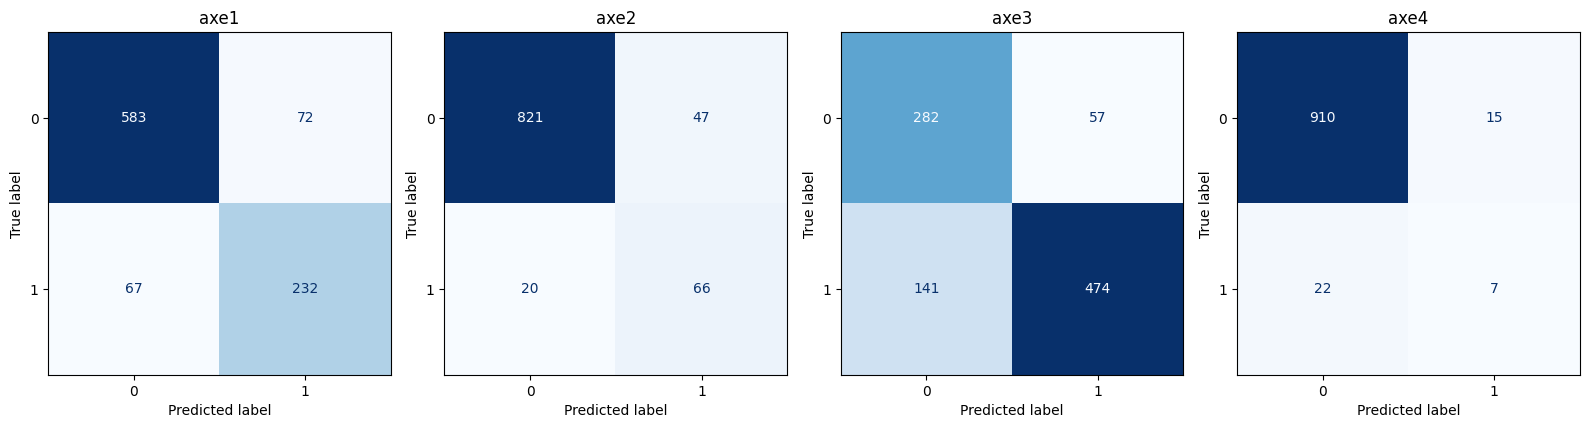

In [17]:
# + clip, +weight, +epochs， + oversampling
#-------------------------------- evaluate mlp model on X_val---------------------------------------
importlib.reload(auto_completion)
from utils.auto_completion import evaluate_model, predict_by_mlp
preds_mlp, probs_mlp = predict_by_mlp(X_val, mlp_model, threshold=best_t_overall)
evaluate_model(preds_mlp, y_val)

## lr (skip):

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import StandardScaler

#----------------- 取 axe4 标签-----------------
y_train_axe4 = y_train[:, 3]  # 第4列
y_val_axe4 = y_val[:, 3]

# under+over sampling!
# Step 1: undersample majority class
rus = RandomUnderSampler(sampling_strategy={0: 800})  # 把0减少到500
X_train_res, y_train_res = rus.fit_resample(X_train, y_train_axe4)

# Step 2: SMOTE minority class
smote = SMOTE(sampling_strategy=0.6)
X_train_res, y_train_res = smote.fit_resample(X_train_res, y_train_res)
print(f"[INFO] BEFORE oversampling :\n{pd.Series(y_train_axe4).value_counts()}\n")
print(f'AFTER oversampling :\n{pd.Series(y_train_res).value_counts()}\n')


# 初始化 LR
# class_weight='balanced' 会自动按类别样本数调整权重
lr_axe4 = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')

# 训练
lr_axe4.fit(X_train_res, y_train_res)#*

# ------------------LR 预测----------------------
y_val_pred_prob = lr_axe4.predict_proba(X_val)[:, 1]  # 概率
# 可以选择一个阈值 0.5 或调整
# threshold = 0.5

# 现在 LR 默认阈值是 0.5，可以根据 ROC/PR 曲线选择一个更高 recall 的阈值。
y_scores = lr_axe4.predict_proba(X_val)[:,1]
prec, rec, thresh = precision_recall_curve(y_val[:,3], y_scores)
# 选取让 F1 最大的 threshold
f1_scores = 2*prec*rec/(prec+rec+1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresh[best_idx]
print(f'best threshold by ROC/PR :{best_threshold}\n')

y_val_pred = (y_val_pred_prob >= best_threshold).astype(int)

# 输出性能
print("[Logistic Regression] axe4 classification report:\n")
print(classification_report(y_val_axe4, y_val_pred, digits=4))


[INFO] BEFORE oversampling :
0.0    3723
1.0      90
Name: count, dtype: int64

AFTER oversampling :
0.0    800
1.0    480
Name: count, dtype: int64

best threshold by ROC/PR :0.7331894302406211

[Logistic Regression] axe4 classification report:

              precision    recall  f1-score   support

         0.0     0.9840    0.9903    0.9872       932
         1.0     0.4375    0.3182    0.3684        22

    accuracy                         0.9748       954
   macro avg     0.7108    0.6543    0.6778       954
weighted avg     0.9714    0.9748    0.9729       954



## LR + LGB:

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import classification_report, precision_recall_curve, f1_score
import joblib

lr_model_path="../model/best_lr_3emb.pt"
lgb_model_path="../model/best_lgb_3emb.txt"


#----------------- take labels 'axe4'-----------------
y_train_axe4 = y_train[:, 3]  
y_val_axe4 = y_val[:, 3]


# ----------------resampling: under+over--------------
rus = RandomUnderSampler(sampling_strategy=0.5, random_state=42)   # 保留部分多数类，一半？
X_rus, y_rus = rus.fit_resample(X_train, y_train_axe4)

sm = SMOTE(sampling_strategy=1, random_state=42)  # 0.5-1 根据需要
X_bal, y_bal = sm.fit_resample(X_rus, y_rus) # bal=balanced 

print("After resample y_train_axe4:", pd.Series(y_train_axe4).value_counts())
print("After resample y_val:", pd.Series(y_bal).value_counts())


# ---------------- 2) Standardization for LR ----------
scaler = StandardScaler()
X_bal_s = scaler.fit_transform(X_bal)
X_val_s = scaler.transform(X_val)


# ---------------- 3) Logistic Regression --------------
lr = LogisticRegression(max_iter=2000)
lr.fit(X_bal_s, y_bal)

# calibration :  less extreme probs
#小类的预测概率会更合理，不会全部接近 0。阈值选择不再极端，更稳定。
cal_lr = CalibratedClassifierCV(lr, method='isotonic', cv='prefit')  # or 'sigmoid'
cal_lr.fit(X_val_s, y_val_axe4)  # 小数据集上可用验证集做calibration

#--------------------4) prediction--------------------
lr_model=cal_lr
probs_lr = lr_model.predict_proba(X_val_s)[:,1]
prob_true, prob_pred = calibration_curve(y_val_axe4, probs_lr, n_bins=10)

## save
joblib.dump(cal_lr, lr_model_path)
print(f"[SAVE] LR model saved to {lr_model_path}")


# ------------------ 5) LightGBM -----------------------
train_data = lgb.Dataset(X_bal, label=y_bal)
params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'min_data_in_leaf': 20,
    'max_depth': -1,
    'seed': 42,
    # 'scale_pos_weight': (len(y_bal)-y_bal.sum())/y_bal.sum()  # 可选
}
lgb_model = lgb.train(params, train_data, num_boost_round=500)#bst（boosted tree）
probs_lgb = lgb_model.predict(X_val)

## save :
lgb_model.save_model(lgb_model_path)
print(f"[SAVE] LGB model saved to {lgb_model_path}")


# --------------- 6) Threshold search (PR based) ----------
def best_thresh_by_pr(y_true, probs):
    prec, rec, th = precision_recall_curve(y_true, probs)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    # th length = len(prec)-1 ; align accordingly
    best_idx = np.nanargmax(f1)
    # handle if best_idx equals last of prec (no threshold)
    if best_idx >= len(th):
        return 0.5
    return th[best_idx]

t_lr = best_thresh_by_pr(y_val_axe4, probs_lr)
t_lgb = best_thresh_by_pr(y_val_axe4, probs_lgb)
t_lgb=0.9
print("best t lr:", t_lr, "best t lgb:", t_lgb)

pred_lr = (probs_lr >= t_lr).astype(int)
pred_lgb = (probs_lgb >= t_lgb).astype(int)

print("[LR] axe4")
print(classification_report(y_val_axe4, pred_lr, digits=4))
print("[LGB] axe4")
print(classification_report(y_val_axe4, pred_lgb, digits=4))


# ------------- 7) fusion by F1 weights-----------------------
#按照F1权重合并零个models的probs，通过该prob_ens得出t_ens再得出标签
f1_lr = f1_score(y_val_axe4, pred_lr)
f1_lgb = f1_score(y_val_axe4, pred_lgb)
print(f"F1 LR + LGB : {f1_lr}, {f1_lgb}")

w_lr = f1_lr / (f1_lr + f1_lgb + 1e-12)# w=weight
w_lgb = f1_lgb / (f1_lr + f1_lgb + 1e-12)

proba_ensemble = w_lr * probs_lr + w_lgb * probs_lgb
t_ens = best_thresh_by_pr(y_val_axe4, proba_ensemble)# t_ens=threshold of ensemble
print(f"best t ensemble: {t_ens}")
pred_ens = (proba_ensemble >= t_ens).astype(int)
print("[Ensemble] axe4")
print(classification_report(y_val_axe4, pred_ens, digits=4))


After resample y_train_axe4: 0.0    3723
1.0      90
Name: count, dtype: int64
After resample y_val: 0.0    180
1.0    180
Name: count, dtype: int64
[SAVE] LR model saved to ../model/best_lr_3emb.pt


d:\miniconda3\envs\irg_env\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


[SAVE] LGB model saved to ../model/best_lgb_3emb.txt
best t lr: 0.25 best t lgb: 0.9
[LR] axe4
              precision    recall  f1-score   support

         0.0     0.9861    0.9893    0.9877       932
         1.0     0.4737    0.4091    0.4390        22

    accuracy                         0.9759       954
   macro avg     0.7299    0.6992    0.7134       954
weighted avg     0.9743    0.9759    0.9750       954

[LGB] axe4
              precision    recall  f1-score   support

         0.0     0.9869    0.9732    0.9800       932
         1.0     0.2857    0.4545    0.3509        22

    accuracy                         0.9612       954
   macro avg     0.6363    0.7139    0.6654       954
weighted avg     0.9708    0.9612    0.9655       954

F1 LR + LGB : 0.43902439024390244, 0.3508771929824561
best t ensemble: 0.5235931767187783
[Ensemble] axe4
              precision    recall  f1-score   support

         0.0     0.9872    0.9946    0.9909       932
         1.0     0.6667  

## comparaison：

Micro  F1:  0.7879093198992443
Macro  F1:  0.700142039539857
Micro Precision: 0.7704433497536946
Micro Recall: 0.8061855670103093
Hamming loss: 0.11032494758909853
Subset exact match: 0.7117400419287212

Per-class classification report:
              precision    recall  f1-score   support

        axe1       0.78      0.76      0.77       304
        axe2       0.77      0.58      0.66       113
        axe3       0.77      0.89      0.83       531
        axe4       0.67      0.45      0.54        22

   micro avg       0.77      0.81      0.79       970
   macro avg       0.75      0.67      0.70       970
weighted avg       0.77      0.81      0.78       970
 samples avg       0.77      0.81      0.78       970



d:\miniconda3\envs\irg_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


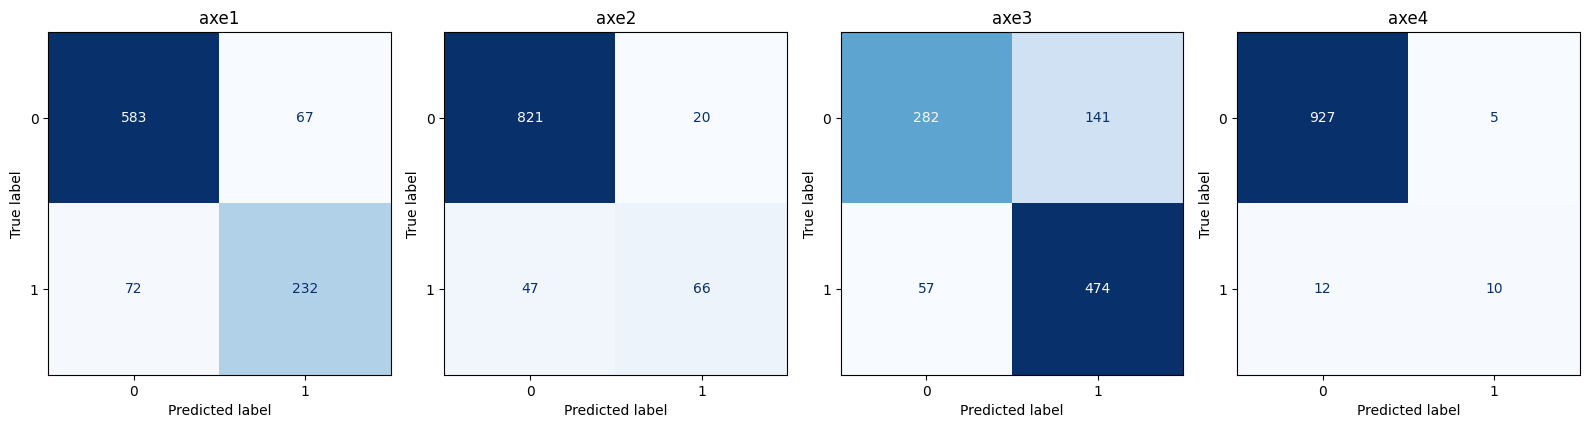

In [20]:
# LR+GBM+MLP
importlib.reload(auto_completion)
from utils.auto_completion import predict_by_mlp, evaluate_model
preds_val_mlp, probs_val_mlp = predict_by_mlp(X_val, mlp_model, threshold=best_t_overall)

# final_axe :MLP for axe12, LR+LGB for axe4
pred_final = np.zeros_like(y_val)
pred_final[:, :3] = (probs_val_mlp[:, :3] >= best_t_overall[:3]).astype(int)
pred_final[:, 3] = pred_ens  # LR 预测 axe4
evaluate_model(y_true=y_val, y_pred=pred_final)


In [21]:
## mlp自己pred的结果：
import torch
import numpy as np

preds_val_mlp, logits=predict_by_mlp(X_val, mlp_model, threshold=best_t_overall)
# 取 axe4 的预测概率
y_val_pred_prob_mlp = logits[:, 3]  # axe4
y_val_pred_mlp = (y_val_pred_prob_mlp >= best_t_overall[3]).astype(int)

print("[MLP] axe4 classification report:")
print(classification_report(y_val_axe4, y_val_pred_mlp, digits=4))

[MLP] axe4 classification report:
              precision    recall  f1-score   support

         0.0     0.9838    0.9764    0.9801       932
         1.0     0.2414    0.3182    0.2745        22

    accuracy                         0.9612       954
   macro avg     0.6126    0.6473    0.6273       954
weighted avg     0.9667    0.9612    0.9638       954



Micro  F1:  0.7800498753117207
Macro  F1:  0.6527262026503358
Micro Precision: 0.7555555555555555
Micro Recall: 0.8061855670103093
Hamming loss: 0.11556603773584906
Subset exact match: 0.6981132075471698

Per-class classification report:
              precision    recall  f1-score   support

        axe1       0.78      0.76      0.77       304
        axe2       0.77      0.58      0.66       113
        axe3       0.77      0.89      0.83       531
        axe4       0.29      0.45      0.35        22

   micro avg       0.76      0.81      0.78       970
   macro avg       0.65      0.67      0.65       970
weighted avg       0.76      0.81      0.78       970
 samples avg       0.76      0.81      0.78       970



d:\miniconda3\envs\irg_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


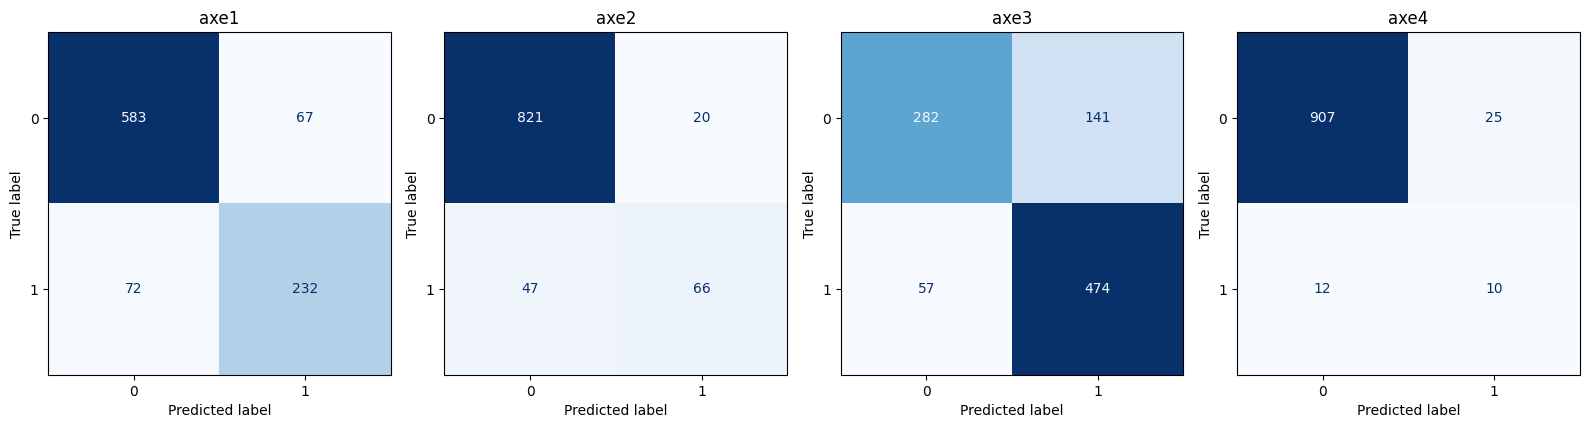

In [23]:
# GBM+MLP
importlib.reload(auto_completion)
from utils.auto_completion import predict_by_mlp,evaluate_model
preds_val_mlp, probs_val_mlp = predict_by_mlp(X_val, mlp_model, threshold=best_t_overall)

# final_axe :MLP for axe12, LR+LGB for axe4
pred_final = np.zeros_like(y_val)
pred_final[:, :3] = (probs_val_mlp[:, :3] >= best_t_overall[:3]).astype(int)
pred_final[:, 3] = pred_lgb  
evaluate_model(y_true=y_val, y_pred=pred_final)


Micro  F1:  0.7853192559074912
Macro  F1:  0.6747630019656974
Micro Precision: 0.7664376840039254
Micro Recall: 0.8051546391752578
Hamming loss: 0.11189727463312368
Subset exact match: 0.7054507337526206

Per-class classification report:
              precision    recall  f1-score   support

        axe1       0.78      0.76      0.77       304
        axe2       0.77      0.58      0.66       113
        axe3       0.77      0.89      0.83       531
        axe4       0.47      0.41      0.44        22

   micro avg       0.77      0.81      0.79       970
   macro avg       0.70      0.66      0.67       970
weighted avg       0.77      0.81      0.78       970
 samples avg       0.77      0.81      0.78       970



d:\miniconda3\envs\irg_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


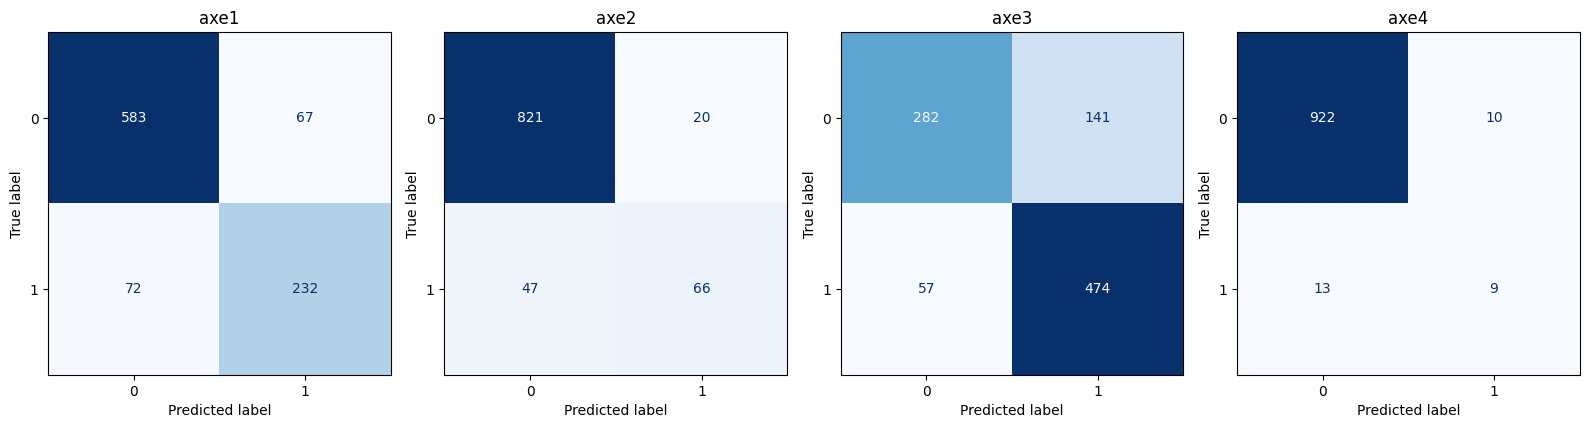

In [25]:
# LR+MLP：
importlib.reload(auto_completion)
from utils.auto_completion import predict_by_mlp,evaluate_model
preds_val_mlp, probs_val_mlp = predict_by_mlp(X_val, mlp_model, threshold=best_t_overall)


# final_axe :MLP for axe12, LR+LGB for axe4
pred_final = np.zeros_like(y_val)
pred_final[:, :3] = (probs_val_mlp[:, :3] >= best_t_overall[:3]).astype(int)
pred_final[:, 3] = pred_lr  
evaluate_model(y_true=y_val, y_pred=pred_final)
# plot_confusion_matrices(y_true=y_val, y_pred=pred_final)



## appli :

In [31]:
importlib.reload(auto_completion)
from utils.auto_completion import apply_auto_completion_axes
import matplotlib
import matplotlib.pyplot as plt
df_all_pred=apply_auto_completion_axes(df_all_path="data/20251201-ProductionScientifiqueIRG-__-202512_2734art.csv",
                            df_all_outpath="data_axe/20251201-ProductionScientifiqueIRG-__-202512_2734art_predaxe.csv",
                            df_all_emb_path="../external_data/df_all_3emb.parquet",
                            noaxe_pq_path='../external_data/df_noaxe_3emb.parquet',
                            mlp_model_path="../model/best_mlp_3emb_2.pt",
                            lr_model_path="../model/best_lr_3emb.pt",
                            lgb_model_path="../model/best_lgb_3emb.txt",
                            t_lr=0.25, t_lgb=0.95, f1_lr=0.44, f1_lgb=0.35, t_ens=0.52
                            )




[ETAPE1] Lire le csv, sélectionner les lignes qui n'ont pas d'axes => df_noaxe

Index(['halId_s', 'uri_s', 'docType_s', 'title_s', 'subTitle_s',
       'authFullName_s', 'authIdHal_s', 'labStructName_s',
       'author_primarystructure_s', 'collName_s', 'collCode_s', 'domain_s',
       'openAccess_bool', 'volume_s', 'page_s', 'axe', 'predicted_axe',
       'submittedDate_s', 'modifiedDate_s', 'publicationDate_s',
       'journalTitle_s', 'cl_fnege', 'conferenceTitle_s',
       'conferenceOrganizer_s', 'conferenceStartDate_s', 'country_s',
       'language_s', 'keyword_s', 'abstract_s', 'files_s', 'urlFulltextEsr_s',
       'fnege_year', 'final_axe'],
      dtype='object')
[INFO] Répartition des axes: 
axe
3          1107
1           684
NaN         617
2           252
4            46
1; 3         11
2; 3          8
1; 2          6
1; 2; 3       1
3; 1          1
3; 4          1
Name: count, dtype: int64

- len df_all: 2734
- len df_noaxe: 617
- len df_hasaxe:2117

[ETAPE2] split axe e

,halId_s,title_s,keyword_s,abstract_s,axe,predicted_axe
22,hal-05306451,Chapitre 10 – Le cas particulier de la collect...,NaN,NaN,NaN,
24,hal-05306441,Chapitre 8 – Les outils traditionnels du fundr...,NaN,NaN,NaN,
25,hal-05306438,Chapitre 7 – Le marché du don et le panorama d...,NaN,NaN,NaN,
161,hal-05004696,Pauvreté transitoire des consommateurs et reco...,Pauvreté chronique; Pauvreté transitoire; Cons...,NaN,NaN,
1252,hal-01765014,Executives' perspectives of the changing role ...,NaN,NaN,NaN,


[INFO] Répartiton des axes prédits sur 617 lignes:
predicted_axe
3             165
1             149
3; 1          136
2              40
4; 3           31
3; 2           26
4; 3; 1        15
4              13
3; 2; 1        11
2; 1            9
4; 1            8
                8
4; 3; 2         4
4; 3; 2; 1      1
4; 2            1
Name: count, dtype: int64



,halId_s,title_s,keyword_s,abstract_s,axe,predicted_axe
0,hal-05388365,Entrepreneuriat de nécessité (versus opportuni...,NaN,Cet article étudie les déterminants de l’entre...,NaN,3; 1
1,hal-05388364,Responsible entrepreneurship: From motivations...,Burkina Faso; GEM; Modèle de la valeur; Entrep...,Cet article étudie les déterminants des modèle...,NaN,3; 1
2,hal-05385243,Agencer des safe spaces en marketing des servi...,Marketing des services; Sécurité; Transformati...,NaN,NaN,2
3,hal-05384860,The Financial Crisis of 1825: The Making of a ...,NaN,NaN,NaN,4
4,hal-05383407,Repenser la responsabilité sociétale des marqu...,CSR; Governance; Strategy; Développement durab...,Cet article propose une grille intégrée d'anal...,NaN,1


Répartiton des axes prédits sur toutes les 2734 lignes:
final_axe
3             1272
1              833
2              292
1; 3           148
4               59
2; 3            34
3; 4            32
1; 2            15
1; 3; 4         15
1; 2; 3         12
1; 4             8
NaN              8
2; 3; 4          4
1; 2; 3; 4       1
2; 4             1
Name: count, dtype: int64



,halId_s,title_s,keyword_s,abstract_s,axe,predicted_axe,final_axe
0,hal-05388365,Entrepreneuriat de nécessité (versus opportuni...,NaN,Cet article étudie les déterminants de l’entre...,NaN,3; 1,1; 3
1,hal-05388364,Responsible entrepreneurship: From motivations...,Burkina Faso; GEM; Modèle de la valeur; Entrep...,Cet article étudie les déterminants des modèle...,NaN,3; 1,1; 3
2,hal-05385243,Agencer des safe spaces en marketing des servi...,Marketing des services; Sécurité; Transformati...,NaN,NaN,2,2
3,hal-05384860,The Financial Crisis of 1825: The Making of a ...,NaN,NaN,NaN,4,4
4,hal-05383407,Repenser la responsabilité sociétale des marqu...,CSR; Governance; Strategy; Développement durab...,Cet article propose une grille intégrée d'anal...,NaN,1,1


[SAVE] df with predicted axis saved to data_axe/20251201-ProductionScientifiqueIRG-__-202512_2734art_predaxe.csv!!

